<a href="https://colab.research.google.com/github/LordRelentless/NGFTSimulations/blob/main/NGFT_multi_observer_Uncertainty_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

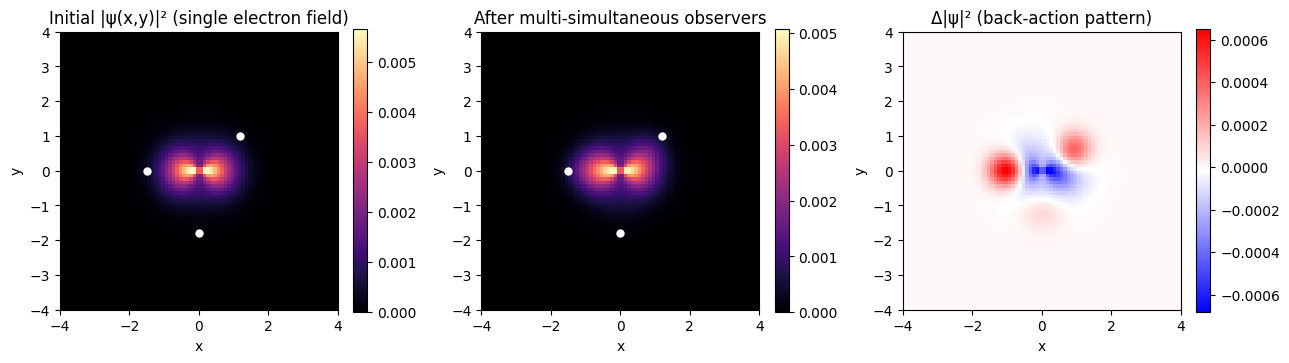

Local intensities seen by observers (∑|ψ|² in their regions):
  Observer 1: 0.0967
  Observer 2: 0.0638
  Observer 3: 0.0194

Check normalization:
  ∑|ψ|² initial: 0.9999999999999996
  ∑|ψ|² after:   0.9999999999999998


In [1]:
# NGFT toy: single-electron informational field for a "carbon" atom
# with multiple simultaneous observers sampling the field.

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. 2D grid and "nuclear informational potential"
# -----------------------------
Nx, Ny = 80, 80
x = np.linspace(-4, 4, Nx)
y = np.linspace(-4, 4, Ny)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

# Carbon-like nucleus: central well + 6-fold angular structure
# (cartoon stand-in for 1s2 2s2 2p2 informational pattern)
V0 = -10.0 * np.exp(-R**2)              # central "1s/2s" well
V6 = -2.0 * np.exp(-R**2) * np.cos(6*Theta)  # 6-fold "2p-like" modulation
V_nuc = V0 + V6

# -----------------------------
# 2. Single electron informational field (amplitude on grid)
# -----------------------------
# Start with a mode shaped by the nuclear potential:
# ground-ish state ~ exp(-alpha R^2) * (1 + beta cos(2*Theta)) as a toy
alpha = 0.6
beta  = 0.3
psi = np.exp(-alpha * R**2) * (1.0 + beta * np.cos(2*Theta))

# Normalize
psi /= np.sqrt(np.sum(np.abs(psi)**2))

# -----------------------------
# 3. Define "observers" as local sampling operators
# -----------------------------
# Each observer samples |psi|^2 in a small region and locally perturbs psi,
# but does NOT collapse the entire field.

def make_observer_mask(cx, cy, sigma=0.4):
    """Gaussian sampling/perturbation region centered at (cx, cy)."""
    dx = X - cx
    dy = Y - cy
    return np.exp(-(dx**2 + dy**2) / (2*sigma**2))

# Place three observers around the atom
obs_centers = [
    (-1.5, 0.0),
    ( 1.2, 1.0),
    ( 0.0,-1.8),
]
obs_masks = [make_observer_mask(cx, cy, sigma=0.5) for (cx, cy) in obs_centers]

# -----------------------------
# 4. Multi-simultaneous observation step (NGFT-style)
# -----------------------------
# Each observer:
# - "reads" local |psi|^2 (what they'd see as intensity)
# - slightly amplifies the local mode they sample (back-action),
#   but we renormalize globally instead of collapsing to a point.

local_intensities = []
psi_obs = psi.copy()

for mask in obs_masks:
    local_I = np.sum(np.abs(psi_obs)**2 * mask)
    local_intensities.append(local_I)

    # Back-action: enhance the sampled region's amplitude a bit
    psi_obs = psi_obs * (1.0 + 0.4 * mask)

# Renormalize after all observers act
psi_obs /= np.sqrt(np.sum(np.abs(psi_obs)**2))

# -----------------------------
# 5. Plot: before vs after multi-observation
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(13,4))

im0 = ax[0].imshow(np.abs(psi)**2, extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='magma')
ax[0].set_title('Initial |ψ(x,y)|² (single electron field)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_obs)**2, extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='magma')
ax[1].set_title('After multi-simultaneous observers')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

# Mark observer positions
for (cx, cy) in obs_centers:
    ax[0].plot(cx, cy, 'wo', ms=5)
    ax[1].plot(cx, cy, 'wo', ms=5)

# Difference map: how much the field was reshaped
diff = np.abs(psi_obs)**2 - np.abs(psi)**2
im2 = ax[2].imshow(diff, extent=[x[0], x[-1], y[0], y[-1]], origin='lower', cmap='bwr')
ax[2].set_title('Δ|ψ|² (back-action pattern)')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

plt.tight_layout()
plt.show()

print("Local intensities seen by observers (∑|ψ|² in their regions):")
for i, I in enumerate(local_intensities):
    print(f"  Observer {i+1}: {I:.4f}")

print("\nCheck normalization:")
print("  ∑|ψ|² initial:", np.sum(np.abs(psi)**2))
print("  ∑|ψ|² after:  ", np.sum(np.abs(psi_obs)**2))

Local intensities seen by which-slit observers:
  Observer at slit 1: 0.0059
  Observer at slit 2: 0.0059


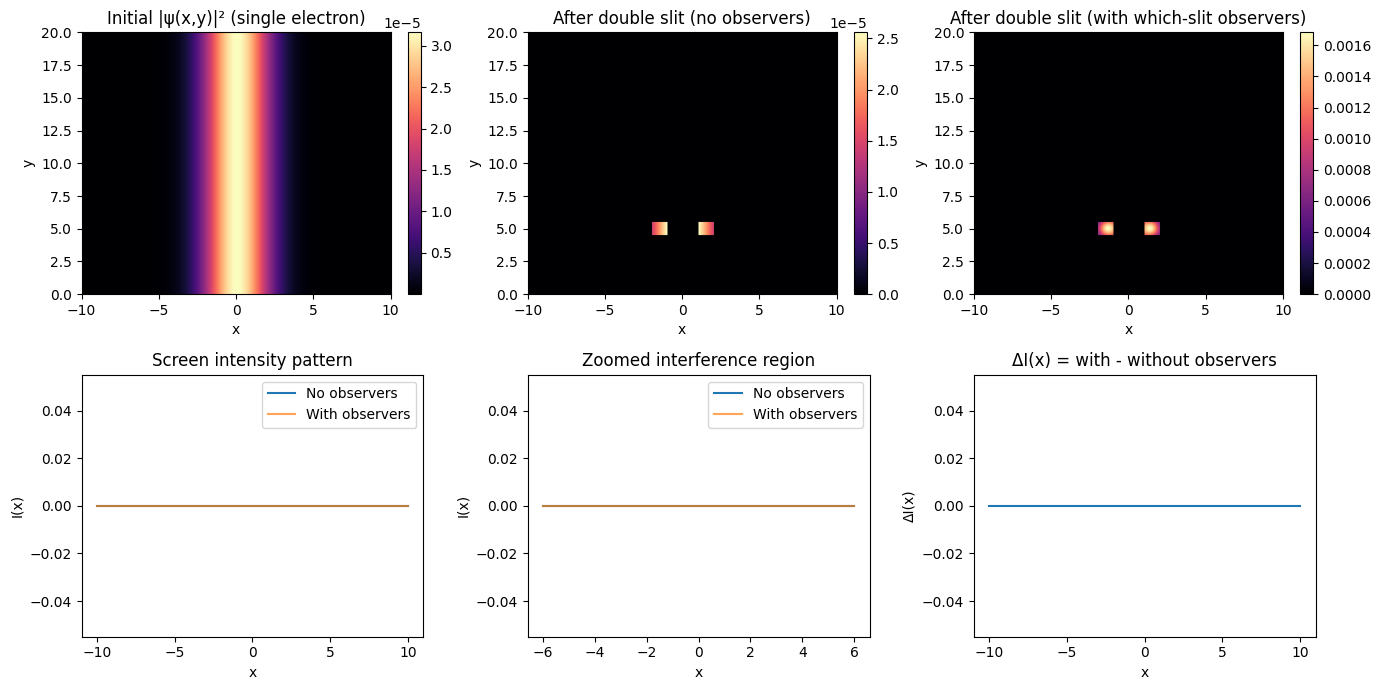


Check normalization at screen:
  ∑I_A: 0.9999999999999999
  ∑I_B: 1.0000000000000002


In [2]:
# NGFT toy: single-electron double-slit with optional which-slit observers

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid and coordinates
# -----------------------------
Nx, Ny = 400, 400
x = np.linspace(-10, 10, Nx)
y = np.linspace(0, 20, Ny)
X, Y = np.meshgrid(x, y)

# -----------------------------
# 2. Initial single-electron field (plane-ish wave)
# -----------------------------
k0 = 3.0  # longitudinal wave number
psi0 = np.exp(1j * k0 * Y) * np.exp(-X**2 / 10.0)  # weak transverse envelope
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2))

# -----------------------------
# 3. Double-slit mask
# -----------------------------
slit_y = 5.0
slit_width = 0.5
slit_sep   = 3.0

mask = np.zeros_like(psi0, dtype=float)
slit_region = np.abs(Y - slit_y) < slit_width

# two slits in x
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_width)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_width)
mask[slit1 | slit2] = 1.0

# Apply mask at slit plane
psi_slit = psi0 * mask

# -----------------------------
# 4. Optional which-slit observers (NGFT-style)
# -----------------------------
def make_observer_mask(center_x, center_y, sigma=0.4):
    dx = X - center_x
    dy = Y - center_y
    return np.exp(-(dx**2 + dy**2) / (2*sigma**2))

# Place observers at each slit (just above the slit plane)
obs_centers = [
    (-slit_sep/2, slit_y),
    ( slit_sep/2, slit_y),
]
obs_masks = [make_observer_mask(cx, cy, sigma=0.5) for (cx, cy) in obs_centers]

def apply_observers(psi, strength=0.6):
    psi_obs = psi.copy()
    local_intensities = []
    for mask_o in obs_masks:
        I_loc = np.sum(np.abs(psi_obs)**2 * mask_o)
        local_intensities.append(I_loc)
        # NGFT-style back-action: enhance sampled region, but no full collapse
        psi_obs = psi_obs * (1.0 + strength * mask_o)
    psi_obs /= np.sqrt(np.sum(np.abs(psi_obs)**2))
    return psi_obs, local_intensities

# Case A: no which-slit observers
psi_after_slit_A = psi_slit.copy()

# Case B: with which-slit observers
psi_after_slit_B, local_I = apply_observers(psi_slit, strength=0.8)

print("Local intensities seen by which-slit observers:")
for i, I in enumerate(local_I):
    print(f"  Observer at slit {i+1}: {I:.4f}")

# -----------------------------
# 5. Propagation to screen (very crude Fresnel-like step)
# -----------------------------
# We'll approximate propagation by applying a simple phase factor in k-space.

def propagate(psi, dy, steps):
    # Fourier in x
    kx = np.fft.fftfreq(Nx, d=(x[1]-x[0])) * 2*np.pi
    KX = np.tile(kx, (Ny,1))
    psi_k = np.fft.fft(psi, axis=1)

    for _ in range(steps):
        phase = np.exp(-1j * (KX**2) * dy / (2*k0))
        psi_k *= phase

    psi_out = np.fft.ifft(psi_k, axis=1)
    psi_out /= np.sqrt(np.sum(np.abs(psi_out)**2))
    return psi_out

dy_prop = 0.05
steps   = 80

psi_screen_A = propagate(psi_after_slit_A, dy_prop, steps)
psi_screen_B = propagate(psi_after_slit_B, dy_prop, steps)

I_A = np.abs(psi_screen_A)**2
I_B = np.abs(psi_screen_B)**2

# Take intensity at final y-row as "screen"
I_screen_A = I_A[-1, :]
I_screen_B = I_B[-1, :]

# -----------------------------
# 6. Plot results
# -----------------------------
fig, ax = plt.subplots(2, 3, figsize=(14,7))

# Initial field
im0 = ax[0,0].imshow(np.abs(psi0)**2, extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='magma', aspect='auto')
ax[0,0].set_title('Initial |ψ(x,y)|² (single electron)')
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0,0], fraction=0.046)

# After slit, no observers
im1 = ax[0,1].imshow(np.abs(psi_after_slit_A)**2, extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='magma', aspect='auto')
ax[0,1].set_title('After double slit (no observers)')
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
plt.colorbar(im1, ax=ax[0,1], fraction=0.046)

# After slit, with observers
im2 = ax[0,2].imshow(np.abs(psi_after_slit_B)**2, extent=[x[0], x[-1], y[0], y[-1]],
                     origin='lower', cmap='magma', aspect='auto')
ax[0,2].set_title('After double slit (with which-slit observers)')
ax[0,2].set_xlabel('x')
ax[0,2].set_ylabel('y')
plt.colorbar(im2, ax=ax[0,2], fraction=0.046)

# Screen patterns
ax[1,0].plot(x, I_screen_A, label='No observers')
ax[1,0].plot(x, I_screen_B, label='With observers', alpha=0.7)
ax[1,0].set_title('Screen intensity pattern')
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('I(x)')
ax[1,0].legend()

# Zoomed interference region
zoom_mask = (x > -6) & (x < 6)
ax[1,1].plot(x[zoom_mask], I_screen_A[zoom_mask], label='No observers')
ax[1,1].plot(x[zoom_mask], I_screen_B[zoom_mask], label='With observers', alpha=0.7)
ax[1,1].set_title('Zoomed interference region')
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('I(x)')
ax[1,1].legend()

# Difference
ax[1,2].plot(x, I_screen_B - I_screen_A)
ax[1,2].set_title('ΔI(x) = with - without observers')
ax[1,2].set_xlabel('x')
ax[1,2].set_ylabel('ΔI(x)')

plt.tight_layout()
plt.show()

print("\nCheck normalization at screen:")
print("  ∑I_A:", np.sum(I_A))
print("  ∑I_B:", np.sum(I_B))

Local intensities seen by which-slit observers (single photon probability in their regions):
  Observer at slit 1: 0.479891
  Observer at slit 2: 0.479906

Check normalization at slit plane:
  ∑|psi_A|^2 dx: 1.0
  ∑|psi_B|^2 dx: 1.0

Check normalization at screen:
  ∑IA dX: 0.9999999999999999
  ∑IB dX: 1.0


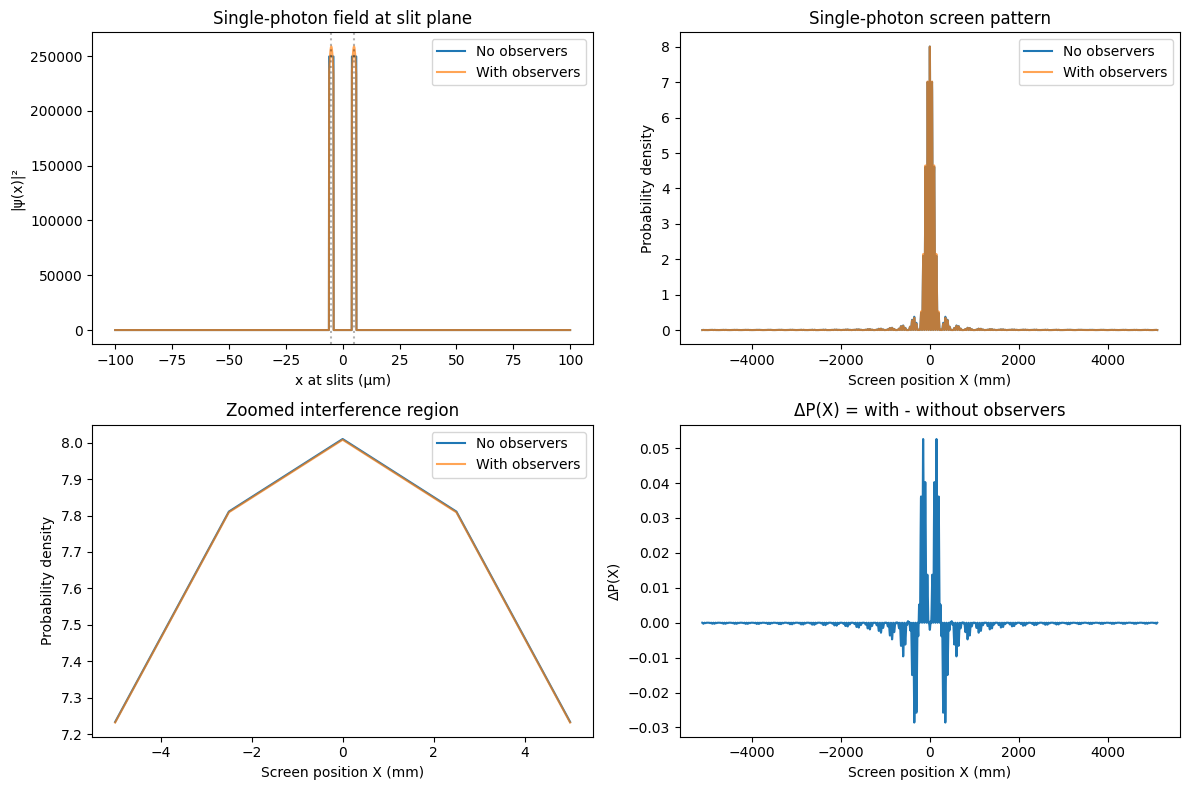

In [3]:
# New Grand Field Theory-style single-photon double-slit with realistic-ish numbers and multiple observers

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Physical-ish parameters
# -----------------------------
lam = 500e-9        # wavelength (500 nm, green light)
k   = 2*np.pi/lam   # wavenumber

# Slit geometry (micron scale)
a   = 2e-6          # slit width (2 µm)
d   = 10e-6         # slit separation center-to-center (10 µm)

# Screen distance (far field)
L   = 1.0           # 1 meter

# Numerical grid at slit plane (x)
Nx  = 4096
x_max = 100e-6      # +/- 100 µm window
x = np.linspace(-x_max, x_max, Nx)
dx = x[1] - x[0]

# -----------------------------
# 2. Single-photon field at slit plane
# -----------------------------
# Treat the photon as a scalar field with uniform amplitude across the slits.
psi_in = np.ones_like(x, dtype=complex)

# Double-slit mask
slit1 = (x > -d/2 - a/2) & (x < -d/2 + a/2)
slit2 = (x >  d/2 - a/2) & (x <  d/2 + a/2)
mask  = np.zeros_like(x, dtype=float)
mask[slit1 | slit2] = 1.0

psi_slit = psi_in * mask

# Normalize as a single-photon wavefunction
psi_slit /= np.sqrt(np.sum(np.abs(psi_slit)**2) * dx)

# -----------------------------
# 3. NGFT-style which-slit observers
# -----------------------------
def observer_mask(center, sigma):
    return np.exp(-(x - center)**2 / (2*sigma**2))

# Observers centered on each slit
sigma_obs = a  # sample roughly the slit width
obs_centers = [-d/2, d/2]
obs_masks = [observer_mask(c, sigma_obs) for c in obs_centers]

def apply_observers(psi, strength=0.8):
    psi_obs = psi.copy()
    local_intensities = []
    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_obs)**2 * m * dx)
        local_intensities.append(I_loc)
        # NGFT back-action: locally reweight the mode, but no full collapse
        psi_obs = psi_obs * (1.0 + strength * m)
    # Renormalize to keep it a single photon
    psi_obs /= np.sqrt(np.sum(np.abs(psi_obs)**2) * dx)
    return psi_obs, local_intensities

# Case A: no which-slit observers
psi_A = psi_slit.copy()

# Case B: with which-slit observers
psi_B, local_I = apply_observers(psi_slit, strength=0.8)

print("Local intensities seen by which-slit observers (single photon probability in their regions):")
for i, I in enumerate(local_I):
    print(f"  Observer at slit {i+1}: {I:.6f}")

print("\nCheck normalization at slit plane:")
print("  ∑|psi_A|^2 dx:", np.sum(np.abs(psi_A)**2 * dx))
print("  ∑|psi_B|^2 dx:", np.sum(np.abs(psi_B)**2 * dx))

# -----------------------------
# 4. Fraunhofer propagation to screen
# -----------------------------
# Far-field pattern ~ Fourier transform of field at slits.
# Screen coordinate X related to kx by X = (lam * L / (2π)) * kx

kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
psiA_k = np.fft.fftshift(np.fft.fft(psi_A))
psiB_k = np.fft.fftshift(np.fft.fft(psi_B))

# Map kx to screen position X
X = (lam * L / (2*np.pi)) * np.fft.fftshift(kx)

IA = np.abs(psiA_k)**2
IB = np.abs(psiB_k)**2

# Normalize intensities as probabilities on screen
dX = X[1] - X[0]
IA /= np.sum(IA * dX)
IB /= np.sum(IB * dX)

print("\nCheck normalization at screen:")
print("  ∑IA dX:", np.sum(IA * dX))
print("  ∑IB dX:", np.sum(IB * dX))

# -----------------------------
# 5. Plot results
# -----------------------------
fig, ax = plt.subplots(2, 2, figsize=(12,8))

# Slit plane field
ax[0,0].plot(x*1e6, np.abs(psi_A)**2, label='No observers')
ax[0,0].plot(x*1e6, np.abs(psi_B)**2, label='With observers', alpha=0.7)
ax[0,0].set_xlabel('x at slits (µm)')
ax[0,0].set_ylabel('|ψ(x)|²')
ax[0,0].set_title('Single-photon field at slit plane')
ax[0,0].legend()

# Mark slit regions
for c in obs_centers:
    ax[0,0].axvline(c*1e6, color='k', linestyle=':', alpha=0.3)

# Screen pattern (full)
ax[0,1].plot(X*1e3, IA, label='No observers')
ax[0,1].plot(X*1e3, IB, label='With observers', alpha=0.7)
ax[0,1].set_xlabel('Screen position X (mm)')
ax[0,1].set_ylabel('Probability density')
ax[0,1].set_title('Single-photon screen pattern')
ax[0,1].legend()

# Zoomed central region
zoom = np.abs(X) < 5e-3  # +/- 5 mm
ax[1,0].plot(X[zoom]*1e3, IA[zoom], label='No observers')
ax[1,0].plot(X[zoom]*1e3, IB[zoom], label='With observers', alpha=0.7)
ax[1,0].set_xlabel('Screen position X (mm)')
ax[1,0].set_ylabel('Probability density')
ax[1,0].set_title('Zoomed interference region')
ax[1,0].legend()

# Difference
ax[1,1].plot(X*1e3, IB - IA)
ax[1,1].set_xlabel('Screen position X (mm)')
ax[1,1].set_ylabel('ΔP(X)')
ax[1,1].set_title('ΔP(X) = with - without observers')

plt.tight_layout()
plt.show()

Local intensities seen by observers (single photon probability in their regions):
  Center: 0.013938
  Right (on left path): 0.008011
  Left (on right path): 0.008016

Normalization check:
  ∑|psi_A|^2 dx dy: 1.0
  ∑|psi_B|^2 dx dy: 0.9999999999999999


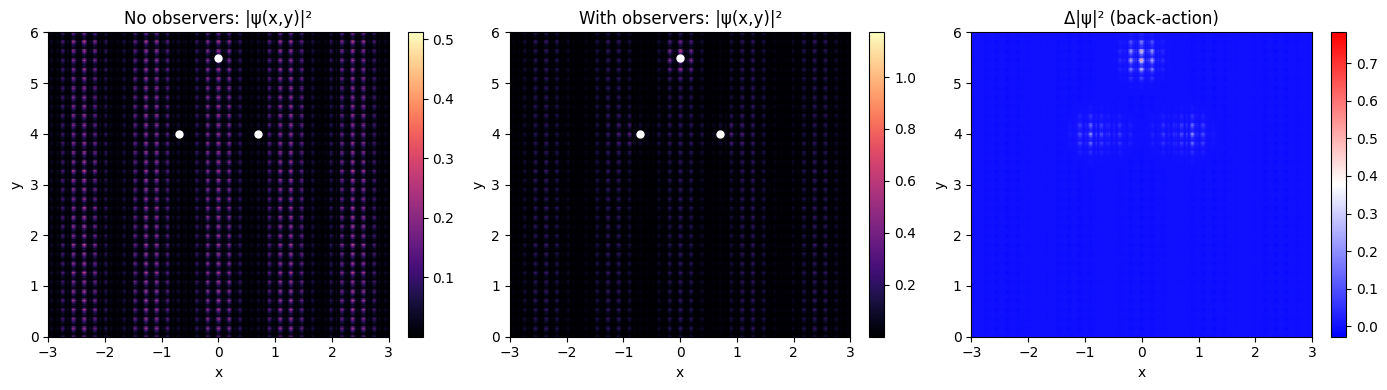

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
# Source at (0, 0), slits at y = 1
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi = np.zeros_like(X, dtype=complex)

# Initial "emission" as a Gaussian at source
src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi += src_mask * np.exp(1j * 8*Y)  # upward-ish phase

# Double slit mask at y ~ 1
slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi *= mask_slit

# Normalize
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)

# -----------------------------
# 3. Define "mirror" regions
# -----------------------------
# We'll approximate mirrors as narrow lines that redirect phase
# Path: slits -> first mirrors at y ~ 2.5, then to second mirrors at y ~ 4.0, then reconverge near y ~ 5.5

# First mirrors (45°): left and right
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

# Second mirrors (30°): left and right
m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Simple propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate(psi, steps, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    for _ in range(steps):
        psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action: redirect phase
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()
    # First mirrors: add phase kicks that steer beams toward second mirrors
    # Left slit -> rightward/upward; right slit -> leftward/upward
    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    # Second mirrors: steer both toward center (0, ~5.5)
    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

# Central reconvergence point
center = (0.0, 5.5)
# Right observer looking along left path (near m2L)
obs_R = (-0.7, 4.0)
# Left observer looking along right path (near m2R)
obs_L = (0.7, 4.0)

obs_centers = [center, obs_R, obs_L]
obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

def apply_observers(psi, strength=0.6):
    psi_o = psi.copy()
    local_I = []
    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)
        psi_o = psi_o * (1.0 + strength * m)
    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)
    return psi_o, local_I

# -----------------------------
# 7. Evolve: slits -> mirrors -> reconvergence
# -----------------------------
# Step 1: propagate from slits to first mirrors
psi1 = propagate(psi, steps=15, dz=0.05)

# Step 2: apply mirrors
psi2 = apply_mirrors(psi1)

# Step 3: propagate to reconvergence region
psi3 = propagate(psi2, steps=20, dz=0.05)

# Case A: no observers
psi_A = psi3.copy()

# Case B: with observers
psi_B, local_I = apply_observers(psi3, strength=0.8)

print("Local intensities seen by observers (single photon probability in their regions):")
labels = ["Center", "Right (on left path)", "Left (on right path)"]
for lab, I in zip(labels, local_I):
    print(f"  {lab}: {I:.6f}")

print("\nNormalization check:")
print("  ∑|psi_A|^2 dx dy:", np.sum(np.abs(psi_A)**2) * dx * dy)
print("  ∑|psi_B|^2 dx dy:", np.sum(np.abs(psi_B)**2) * dx * dy)

# -----------------------------
# 8. Plot
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(14,4))

im0 = ax[0].imshow(np.abs(psi_A)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title('No observers: |ψ(x,y)|²')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_B)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title('With observers: |ψ(x,y)|²')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

diff = np.abs(psi_B)**2 - np.abs(psi_A)**2
im2 = ax[2].imshow(diff, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='bwr', aspect='auto')
ax[2].set_title('Δ|ψ|² (back-action)')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

# Mark observers
for (cx, cy) in obs_centers:
    for a in ax[:2]:
        a.plot(cx, cy, 'wo', ms=5)

plt.tight_layout()
plt.show()

Local intensities seen by observers:
  Center: 0.013938
  Right (on left path): 0.008011
  Left (on right path): 0.008016
  Mirror 1 Left: 0.010905
  Mirror 1 Right: 0.010905
  Mirror 2 Left: 0.014449
  Mirror 2 Right: 0.014454

Normalization check:
  ∑|psi_A|^2 dx dy: 1.0
  ∑|psi_B|^2 dx dy: 1.0000000000000002


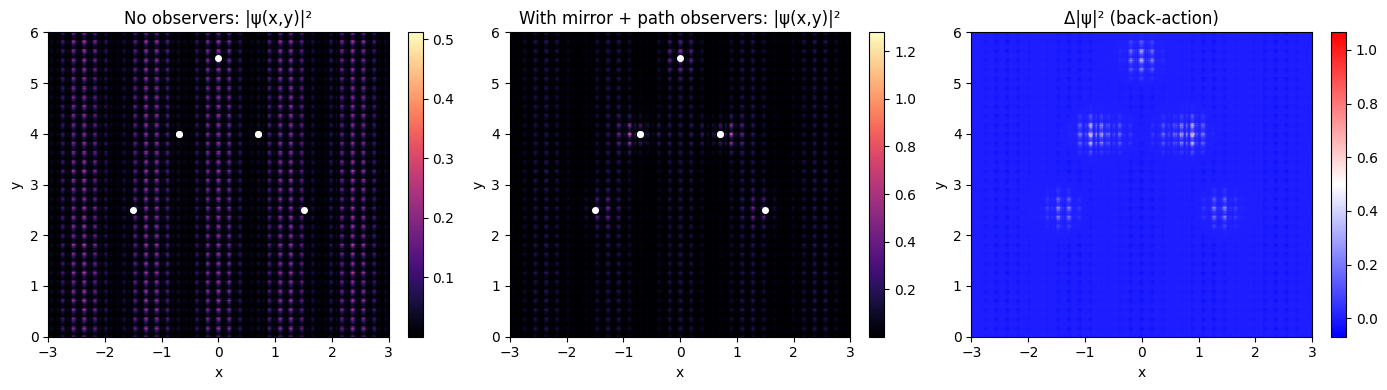

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi *= mask_slit
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate(psi, steps, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    for _ in range(steps):
        psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

# Original three observers (same positions as before)
center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

# New observers looking directly at mirrors
obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

def apply_observers(psi, strength=0.6):
    psi_o = psi.copy()
    local_I = []
    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)
        psi_o = psi_o * (1.0 + strength * m)
    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)
    return psi_o, local_I

# -----------------------------
# 7. Evolve
# -----------------------------
psi1 = propagate(psi, steps=15, dz=0.05)
psi2 = apply_mirrors(psi1)
psi3 = propagate(psi2, steps=20, dz=0.05)

psi_A = psi3.copy()
psi_B, local_I = apply_observers(psi3, strength=0.8)

print("Local intensities seen by observers:")
for lab, I in zip(labels, local_I):
    print(f"  {lab}: {I:.6f}")

print("\nNormalization check:")
print("  ∑|psi_A|^2 dx dy:", np.sum(np.abs(psi_A)**2) * dx * dy)
print("  ∑|psi_B|^2 dx dy:", np.sum(np.abs(psi_B)**2) * dx * dy)

# -----------------------------
# 8. Plot
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(14,4))

im0 = ax[0].imshow(np.abs(psi_A)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title('No observers: |ψ(x,y)|²')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_B)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title('With mirror + path observers: |ψ(x,y)|²')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

diff = np.abs(psi_B)**2 - np.abs(psi_A)**2
im2 = ax[2].imshow(diff, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='bwr', aspect='auto')
ax[2].set_title('Δ|ψ|² (back-action)')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax[:2]:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

Local intensities and info transfer:
  Center: I = 0.013938, ΔI = 0.011151
  Right (on left path): I = 0.008011, ΔI = 0.006409
  Left (on right path): I = 0.008016, ΔI = 0.006413
  Mirror 1 Left: I = 0.010905, ΔI = 0.008724
  Mirror 1 Right: I = 0.010905, ΔI = 0.008724
  Mirror 2 Left: I = 0.014449, ΔI = 0.011559
  Mirror 2 Right: I = 0.014454, ΔI = 0.011564

Total information extracted ΣΔI = 0.064543
Photon entropy budget S_gamma = 0.030000

Normalization:
  ∑|psi_before_obs|^2 dx dy: 1.0
  ∑|psi_NGFT|^2 dx dy:       1.0000000000000002

Collapse decision (A): Left path
  ∑|psi_path|^2 dx dy:    0.9999999999999999
Collapse (B) to center line:
  ∑|psi_center|^2 dx dy: 0.9999999999999999


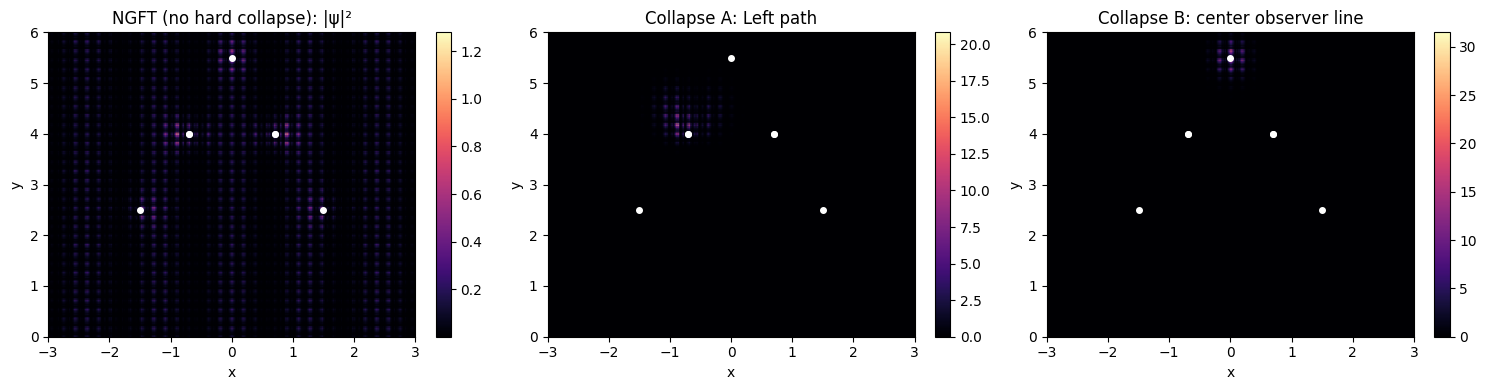

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi *= mask_slit
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate(psi, steps, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    for _ in range(steps):
        psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers + info budget
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

# Original three observers
center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

# Mirror observers
obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

observer_strength = 0.8
info_scale = 1.0   # arbitrary scaling for info units
S_gamma = 0.03     # photon informational entropy budget (toy value)

def apply_observers_with_info(psi):
    psi_o = psi.copy()
    local_I = []
    local_info = []
    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)
        dI = info_scale * observer_strength * I_loc
        local_info.append(dI)
        psi_o = psi_o * (1.0 + observer_strength * m)
    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)
    total_info = np.sum(local_info)
    return psi_o, local_I, local_info, total_info

# -----------------------------
# 7. Evolve to reconvergence
# -----------------------------
psi1 = propagate(psi, steps=15, dz=0.05)
psi2 = apply_mirrors(psi1)
psi3 = propagate(psi2, steps=20, dz=0.05)

psi_before_obs = psi3.copy()
psi_NGFT, local_I, local_info, total_info = apply_observers_with_info(psi3)

print("Local intensities and info transfer:")
for lab, I, dI in zip(labels, local_I, local_info):
    print(f"  {lab}: I = {I:.6f}, ΔI = {dI:.6f}")
print(f"\nTotal information extracted ΣΔI = {total_info:.6f}")
print(f"Photon entropy budget S_gamma = {S_gamma:.6f}")
print("\nNormalization:")
print("  ∑|psi_before_obs|^2 dx dy:", np.sum(np.abs(psi_before_obs)**2) * dx * dy)
print("  ∑|psi_NGFT|^2 dx dy:      ", np.sum(np.abs(psi_NGFT)**2) * dx * dy)

# -----------------------------
# 8. Collapse rules (A and B) if ΣΔI >= S_gamma
# -----------------------------
# Define path masks near second mirrors (left/right arms)
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)

# Center observer line mask
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

if total_info >= S_gamma:
    # A) Collapse to single path: choose arm with higher intensity
    I_L = np.sum(np.abs(psi_NGFT)**2 * path_L_mask * dx * dy)
    I_R = np.sum(np.abs(psi_NGFT)**2 * path_R_mask * dx * dy)
    if I_L >= I_R:
        psi_path = project_and_normalize(psi_NGFT, path_L_mask)
        chosen_path = "Left path"
    else:
        psi_path = project_and_normalize(psi_NGFT, path_R_mask)
        chosen_path = "Right path"

    # B) Collapse to center observer line (tunneling-like)
    psi_center = project_and_normalize(psi_NGFT, center_line_mask)
else:
    psi_path = psi_NGFT.copy()
    psi_center = psi_NGFT.copy()
    chosen_path = "No collapse (info below threshold)"

print(f"\nCollapse decision (A): {chosen_path}")
print("  ∑|psi_path|^2 dx dy:   ", np.sum(np.abs(psi_path)**2) * dx * dy)
print("Collapse (B) to center line:")
print("  ∑|psi_center|^2 dx dy:", np.sum(np.abs(psi_center)**2) * dx * dy)

# -----------------------------
# 9. Plot: NGFT vs path-collapse vs center-collapse
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_NGFT)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title('NGFT (no hard collapse): |ψ|²')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_path)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {chosen_path}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_center)**2, extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

Collapse triggered: True
Collapse point: to_m1_step_1
Collapse type (A): Right path
Total cumulative info Σ(ΔI_ext + ΔI_inj): 1.1440889652260728
Photon entropy budget S_gamma: 0.03

Normalization checks:
  ∑|psi_pre_collapse|^2 dx dy: 1.0
  ∑|psi_path|^2 dx dy:         0.9999999999999997
  ∑|psi_center|^2 dx dy:       1.0000000000000002


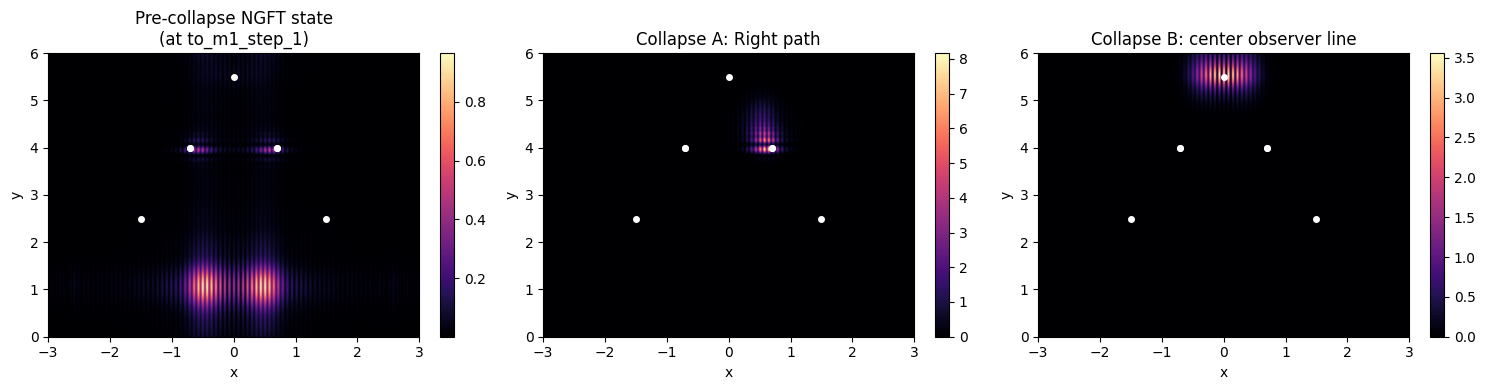

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi0 = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi0 += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi0 *= mask_slit
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate_step(psi, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers + info exchange
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

# Original three observers
center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

# Mirror observers
obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

observer_strength = 0.6
info_scale_extract = 1.0
info_scale_inject  = 1.0
S_gamma = 0.03  # photon informational entropy budget (toy)

def info_exchange_step(psi, cumulative_info):
    psi_o = psi.copy()
    local_I = []
    local_dI_extract = []
    local_dI_inject = []

    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)

        # Extraction: what the observer learns
        dI_ext = info_scale_extract * observer_strength * I_loc
        # Injection: how much the observer reshapes the photon field
        dI_inj = info_scale_inject * observer_strength * I_loc

        local_dI_extract.append(dI_ext)
        local_dI_inject.append(dI_inj)

        # Back-action (injection) on the field
        psi_o = psi_o * (1.0 + observer_strength * m)

    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)

    total_step_info = np.sum(local_dI_extract) + np.sum(local_dI_inject)
    cumulative_info += total_step_info

    return psi_o, cumulative_info, local_I, local_dI_extract, local_dI_inject

# -----------------------------
# 7. Collapse projectors
# -----------------------------
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

# -----------------------------
# 8. Segment-wise evolution with tunable collapse
# -----------------------------
psi = psi0.copy()
cumulative_info = 0.0
collapse_triggered = False
collapse_point = None
collapse_type = None

# Define segments: (label, steps, dz, apply_mirrors_here?)
segments = [
    ("to_m1", 10, 0.05, False),
    ("at_m1",  1, 0.00, True),
    ("to_m2", 10, 0.05, False),
    ("at_m2",  1, 0.00, True),
    ("to_center", 15, 0.05, False),
]

psi_history = {"pre_collapse": None, "path": None, "center": None}

for seg_name, steps, dz, do_mirrors in segments:
    for s in range(steps):
        if dz > 0:
            psi = propagate_step(psi, dz)

        if do_mirrors and s == 0:
            psi = apply_mirrors(psi)

        # Apply observers and info exchange at each substep
        psi, cumulative_info, local_I, dI_ext, dI_inj = info_exchange_step(psi, cumulative_info)

        if not collapse_triggered and cumulative_info >= S_gamma:
            collapse_triggered = True
            collapse_point = f"{seg_name}_step_{s}"
            psi_history["pre_collapse"] = psi.copy()

            # Decide left vs right path
            I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
            I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)

            if I_L >= I_R:
                psi_path = project_and_normalize(psi, path_L_mask)
                collapse_type = "Left path"
            else:
                psi_path = project_and_normalize(psi, path_R_mask)
                collapse_type = "Right path"

            psi_center = project_and_normalize(psi, center_line_mask)

            psi_history["path"] = psi_path
            psi_history["center"] = psi_center

    if collapse_triggered:
        break

print("Collapse triggered:", collapse_triggered)
print("Collapse point:", collapse_point)
print("Collapse type (A):", collapse_type)
print("Total cumulative info Σ(ΔI_ext + ΔI_inj):", cumulative_info)
print("Photon entropy budget S_gamma:", S_gamma)

if psi_history["pre_collapse"] is None:
    psi_history["pre_collapse"] = psi.copy()
    psi_history["path"] = psi.copy()
    psi_history["center"] = psi.copy()
    collapse_type = "No collapse (info below threshold)"

print("\nNormalization checks:")
print("  ∑|psi_pre_collapse|^2 dx dy:", np.sum(np.abs(psi_history['pre_collapse'])**2) * dx * dy)
print("  ∑|psi_path|^2 dx dy:        ", np.sum(np.abs(psi_history['path'])**2) * dx * dy)
print("  ∑|psi_center|^2 dx dy:      ", np.sum(np.abs(psi_history['center'])**2) * dx * dy)

# -----------------------------
# 9. Plot results
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_history["pre_collapse"])**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title(f'Pre-collapse NGFT state\n(at {collapse_point})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_history["path"])**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {collapse_type}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_history["center"])**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

=== Collapse Summary ===
Collapse triggered: True
Collapse point: slit_to_m1_step_1
Observer causing overload: Mirror 2 Right
Collapse type (primary): Right path
Total cumulative info Σ(ΔI_ext + ΔI_inj): 1.1440889652260728
Photon entropy budget S_gamma: 0.03
Final mass complexity M: 6.720444826130365

=== First few interaction steps ===
slit_to_m1_step_0: ΣI=0.0069, M=1.0343
slit_to_m1_step_1: ΣI=0.0616, M=1.3081
slit_to_m1_step_2: ΣI=0.1280, M=1.6402
slit_to_m1_step_3: ΣI=0.2046, M=2.0229
slit_to_m1_step_4: ΣI=0.2977, M=2.4887

Normalization checks:
  ∑|psi_pre_collapse|^2 dx dy: 1.0
  ∑|psi_path|^2 dx dy:         0.9999999999999997
  ∑|psi_center|^2 dx dy:       1.0000000000000002


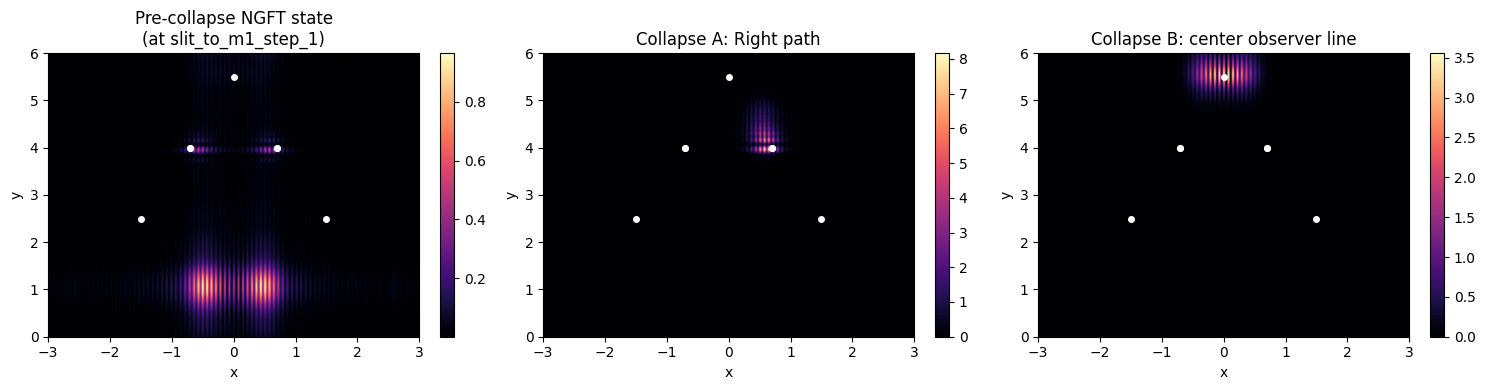

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi0 = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi0 += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi0 *= mask_slit
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate_step(psi, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers + info exchange
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

# Original three observers (final leg)
center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

# Mirror observers
obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

observer_strength = 0.6
info_scale_extract = 1.0
info_scale_inject  = 1.0
S_gamma = 0.03          # photon informational entropy budget (toy)
M0 = 1.0                # base "mass complexity"
mass_alpha = 5.0        # how strongly info raises complexity

def info_exchange_step(psi, cumulative_info):
    psi_o = psi.copy()
    local_I = []
    dI_ext_list = []
    dI_inj_list = []

    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)

        dI_ext = info_scale_extract * observer_strength * I_loc
        dI_inj = info_scale_inject  * observer_strength * I_loc

        dI_ext_list.append(dI_ext)
        dI_inj_list.append(dI_inj)

        psi_o = psi_o * (1.0 + observer_strength * m)

    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)

    total_step_info = np.sum(dI_ext_list) + np.sum(dI_inj_list)
    cumulative_info += total_step_info
    mass_complexity = M0 + mass_alpha * cumulative_info

    return psi_o, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list

# -----------------------------
# 7. Collapse projectors
# -----------------------------
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

# -----------------------------
# 8. Segment-wise evolution with detailed logging
# -----------------------------
psi = psi0.copy()
cumulative_info = 0.0
mass_complexity = M0

collapse_triggered = False
collapse_point = None
collapse_cause_label = None
collapse_type = None

log = []  # store step-by-step info

# segments: name, steps, dz, apply_mirrors_here?
segments = [
    ("slit_to_m1", 10, 0.05, False),
    ("at_m1",       1, 0.00, True),
    ("m1_to_m2",   10, 0.05, False),
    ("at_m2",       1, 0.00, True),
    ("m2_to_final",15, 0.05, False),
]

psi_pre_collapse = None
psi_path = None
psi_center = None

for seg_name, steps, dz, do_mirrors in segments:
    for s in range(steps):
        if dz > 0:
            psi = propagate_step(psi, dz)

        if do_mirrors and s == 0:
            psi = apply_mirrors(psi)

        psi, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list = info_exchange_step(
            psi, cumulative_info
        )

        # log this interaction step
        step_id = f"{seg_name}_step_{s}"
        log.append({
            "step": step_id,
            "cumulative_info": cumulative_info,
            "mass_complexity": mass_complexity,
            "local_I": local_I,
            "dI_ext": dI_ext_list,
            "dI_inj": dI_inj_list,
        })

        if not collapse_triggered and cumulative_info >= S_gamma:
            collapse_triggered = True
            collapse_point = step_id
            psi_pre_collapse = psi.copy()

            # determine which observer contributed most in this step
            total_step_info = np.array(dI_ext_list) + np.array(dI_inj_list)
            max_idx = int(np.argmax(total_step_info))
            collapse_cause_label = labels[max_idx]

            # if center observer caused overload -> collapse to center line
            if collapse_cause_label == "Center":
                psi_center = project_and_normalize(psi, center_line_mask)
                collapse_type = "Center (tunneling-like)"
                # for comparison, still compute path collapse
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
            else:
                # otherwise collapse to left/right path
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                    collapse_type = "Left path"
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
                    collapse_type = "Right path"
                # still compute center collapse for comparison
                psi_center = project_and_normalize(psi, center_line_mask)

    if collapse_triggered:
        break

if not collapse_triggered:
    collapse_point = "No collapse (info below S_gamma)"
    collapse_cause_label = "None"
    collapse_type = "None"
    psi_pre_collapse = psi.copy()
    psi_path = psi.copy()
    psi_center = psi.copy()

print("=== Collapse Summary ===")
print("Collapse triggered:", collapse_triggered)
print("Collapse point:", collapse_point)
print("Observer causing overload:", collapse_cause_label)
print("Collapse type (primary):", collapse_type)
print("Total cumulative info Σ(ΔI_ext + ΔI_inj):", cumulative_info)
print("Photon entropy budget S_gamma:", S_gamma)
print("Final mass complexity M:", mass_complexity)

print("\n=== First few interaction steps ===")
for entry in log[:5]:
    print(f"{entry['step']}: ΣI={entry['cumulative_info']:.4f}, M={entry['mass_complexity']:.4f}")

print("\nNormalization checks:")
print("  ∑|psi_pre_collapse|^2 dx dy:", np.sum(np.abs(psi_pre_collapse)**2) * dx * dy)
print("  ∑|psi_path|^2 dx dy:        ", np.sum(np.abs(psi_path)**2) * dx * dy)
print("  ∑|psi_center|^2 dx dy:      ", np.sum(np.abs(psi_center)**2) * dx * dy)

# -----------------------------
# 9. Plot: pre-collapse, path-collapse, center-collapse
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_pre_collapse)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title(f'Pre-collapse NGFT state\n(at {collapse_point})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_path)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {collapse_type}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_center)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

=== Time-Crystal Collapse Summary ===
Collapse triggered: True
Collapse point: slit_to_m1_step_1
Observer causing overload: Mirror 2 Right
Collapse type (primary): Right path
Total cumulative info Σ(ΔI_ext + ΔI_inj): 1.1440889652260728
Photon entropy budget S_gamma: 0.03
Final mass complexity M: 6.720444826130365

=== First few interaction steps ===
slit_to_m1_step_0: t=5.0000e-02, shutter=1.0, g_eff=0.60, ΣI=0.0069, M=1.0343
slit_to_m1_step_1: t=1.0000e-01, shutter=1.0, g_eff=0.60, ΣI=0.0616, M=1.3081
slit_to_m1_step_2: t=1.5000e-01, shutter=1.0, g_eff=0.60, ΣI=0.1280, M=1.6402
slit_to_m1_step_3: t=2.0000e-01, shutter=1.0, g_eff=0.60, ΣI=0.2046, M=2.0229
slit_to_m1_step_4: t=2.5000e-01, shutter=1.0, g_eff=0.60, ΣI=0.2977, M=2.4887

Normalization checks:
  ∑|psi_pre_collapse|^2 dx dy: 1.0
  ∑|psi_path|^2 dx dy:         0.9999999999999997
  ∑|psi_center|^2 dx dy:       1.0000000000000002


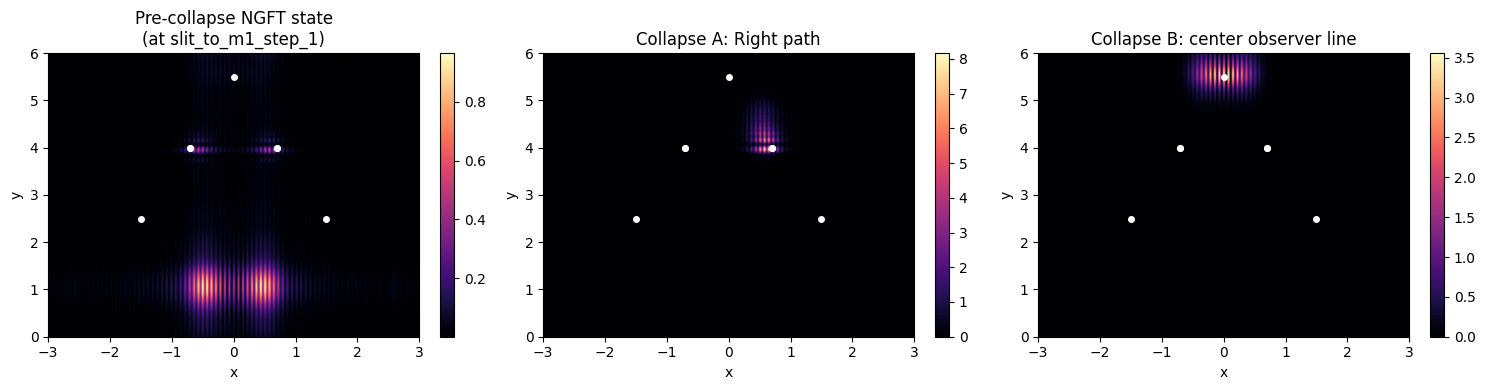

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi0 = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi0 += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi0 *= mask_slit
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate_step(psi, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

# -----------------------------
# 7. Time crystal parameters
# -----------------------------
# Treat dz as a proxy for time step dt (units arbitrary but consistent)
base_dz = 0.05
dt = base_dz  # effective time step

# Characteristic propagation time across apparatus ~ T_prop
# We'll just take T_prop ~ total_steps * dt; we want the time crystal
# to oscillate 1000x faster => many cycles per dt.
T_prop = 1.0
f_TC = 1000.0 / T_prop      # time crystal frequency (arbitrary units)
omega_TC = 2 * np.pi * f_TC

def time_crystal_shutter(t):
    # Binary shutter: on when cos(ω t) > 0, off otherwise
    return 1.0 if np.cos(omega_TC * t) > 0 else 0.0

# -----------------------------
# 8. Info + mass parameters
# -----------------------------
observer_strength_base = 0.6
info_scale_extract = 1.0
info_scale_inject  = 1.0
S_gamma = 0.03
M0 = 1.0
mass_alpha = 5.0

def info_exchange_step_time_crystal(psi, cumulative_info, t):
    psi_o = psi.copy()
    local_I = []
    dI_ext_list = []
    dI_inj_list = []

    shutter = time_crystal_shutter(t)
    g_eff = observer_strength_base * shutter

    for m in obs_masks:
        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)

        dI_ext = info_scale_extract * g_eff * I_loc
        dI_inj = info_scale_inject  * g_eff * I_loc

        dI_ext_list.append(dI_ext)
        dI_inj_list.append(dI_inj)

        psi_o = psi_o * (1.0 + g_eff * m)

    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)

    total_step_info = np.sum(dI_ext_list) + np.sum(dI_inj_list)
    cumulative_info += total_step_info
    mass_complexity = M0 + mass_alpha * cumulative_info

    return psi_o, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff, shutter

# -----------------------------
# 9. Collapse projectors
# -----------------------------
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

# -----------------------------
# 10. Segment-wise evolution with time crystal
# -----------------------------
psi = psi0.copy()
cumulative_info = 0.0
mass_complexity = M0
t = 0.0

collapse_triggered = False
collapse_point = None
collapse_cause_label = None
collapse_type = None

log = []

segments = [
    ("slit_to_m1", 10, base_dz, False),
    ("at_m1",       1, 0.00,    True),
    ("m1_to_m2",   10, base_dz, False),
    ("at_m2",       1, 0.00,    True),
    ("m2_to_final",15, base_dz, False),
]

psi_pre_collapse = None
psi_path = None
psi_center = None

for seg_name, steps, dz, do_mirrors in segments:
    for s in range(steps):
        if dz > 0:
            psi = propagate_step(psi, dz)
            t += dt

        if do_mirrors and s == 0:
            psi = apply_mirrors(psi)

        psi, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff, shutter = \
            info_exchange_step_time_crystal(psi, cumulative_info, t)

        step_id = f"{seg_name}_step_{s}"
        log.append({
            "step": step_id,
            "time": t,
            "shutter": shutter,
            "g_eff": g_eff,
            "cumulative_info": cumulative_info,
            "mass_complexity": mass_complexity,
            "local_I": local_I,
            "dI_ext": dI_ext_list,
            "dI_inj": dI_inj_list,
        })

        if not collapse_triggered and cumulative_info >= S_gamma:
            collapse_triggered = True
            collapse_point = step_id
            psi_pre_collapse = psi.copy()

            total_step_info = np.array(dI_ext_list) + np.array(dI_inj_list)
            max_idx = int(np.argmax(total_step_info))
            collapse_cause_label = labels[max_idx]

            if collapse_cause_label == "Center":
                psi_center = project_and_normalize(psi, center_line_mask)
                collapse_type = "Center (tunneling-like)"
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
            else:
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                    collapse_type = "Left path"
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
                    collapse_type = "Right path"
                psi_center = project_and_normalize(psi, center_line_mask)

    if collapse_triggered:
        break

if not collapse_triggered:
    collapse_point = "No collapse (info below S_gamma)"
    collapse_cause_label = "None"
    collapse_type = "None"
    psi_pre_collapse = psi.copy()
    psi_path = psi.copy()
    psi_center = psi.copy()

print("=== Time-Crystal Collapse Summary ===")
print("Collapse triggered:", collapse_triggered)
print("Collapse point:", collapse_point)
print("Observer causing overload:", collapse_cause_label)
print("Collapse type (primary):", collapse_type)
print("Total cumulative info Σ(ΔI_ext + ΔI_inj):", cumulative_info)
print("Photon entropy budget S_gamma:", S_gamma)
print("Final mass complexity M:", mass_complexity)

print("\n=== First few interaction steps ===")
for entry in log[:5]:
    print(f"{entry['step']}: t={entry['time']:.4e}, shutter={entry['shutter']}, "
          f"g_eff={entry['g_eff']:.2f}, ΣI={entry['cumulative_info']:.4f}, M={entry['mass_complexity']:.4f}")

print("\nNormalization checks:")
print("  ∑|psi_pre_collapse|^2 dx dy:", np.sum(np.abs(psi_pre_collapse)**2) * dx * dy)
print("  ∑|psi_path|^2 dx dy:        ", np.sum(np.abs(psi_path)**2) * dx * dy)
print("  ∑|psi_center|^2 dx dy:      ", np.sum(np.abs(psi_center)**2) * dx * dy)

# -----------------------------
# 11. Plot: pre-collapse, path-collapse, center-collapse
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_pre_collapse)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title(f'Pre-collapse NGFT state\n(at {collapse_point})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_path)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {collapse_type}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_center)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

=== Tunable-Observer Collapse Summary ===
Collapse triggered: True
Collapse point: slit_to_m1_step_1
Observer causing overload: Mirror 2 Right
Collapse type (primary): Right path
Total cumulative info Σ(ΔI_ext + ΔI_inj): 0.9863031671366217
Photon entropy budget S_gamma: 0.03
Final mass complexity M: 5.931515835683109

=== First few interaction steps ===
slit_to_m1_step_0: t=0.050, g_global=0.60, g_eff=[0.60, 0.60, 0.00, 0.60, 0.60, 0.60, 0.60], ΣI=0.0068, M=1.0342
slit_to_m1_step_1: t=0.100, g_global=0.60, g_eff=[0.60, 0.00, 0.60, 0.60, 0.60, 0.60, 0.60], ΣI=0.0478, M=1.2388
slit_to_m1_step_2: t=0.150, g_global=0.60, g_eff=[0.60, 0.60, 0.00, 0.60, 0.60, 0.60, 0.60], ΣI=0.1002, M=1.5010
slit_to_m1_step_3: t=0.200, g_global=0.60, g_eff=[0.60, 0.60, 0.00, 0.60, 0.60, 0.60, 0.60], ΣI=0.1624, M=1.8120
slit_to_m1_step_4: t=0.250, g_global=0.60, g_eff=[0.60, 0.00, 0.00, 0.60, 0.60, 0.60, 0.60], ΣI=0.2211, M=2.1053

Normalization checks:
  ∑|psi_pre_collapse|^2 dx dy: 1.0000000000000002
  ∑|ps

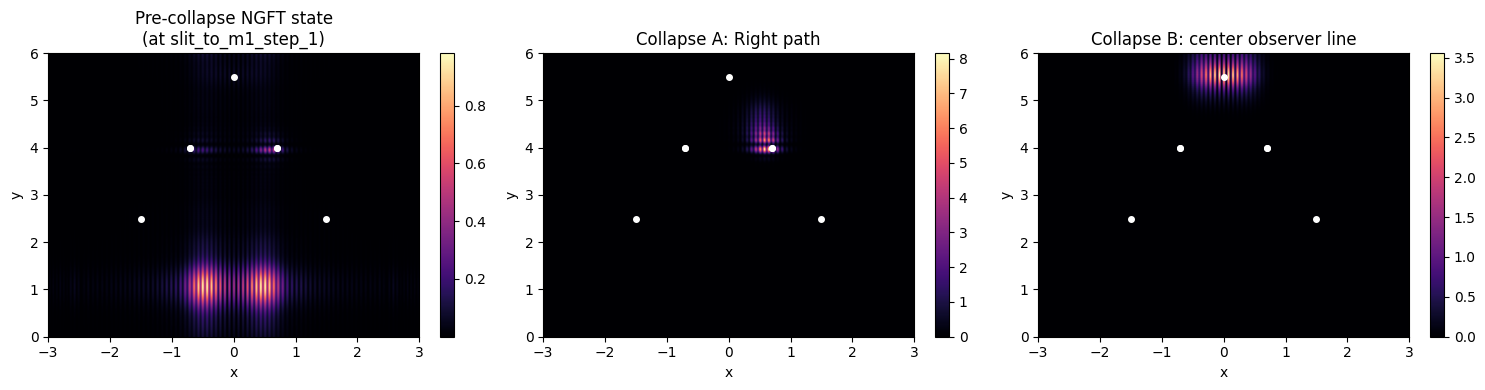

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

psi0 = np.zeros_like(X, dtype=complex)

src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
psi0 += src_mask * np.exp(1j * 8*Y)

slit_region = np.abs(Y - slit_y) < 0.05
slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
mask_slit = np.zeros_like(X, dtype=float)
mask_slit[slit1 | slit2] = 1.0

psi0 *= mask_slit
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate_step(psi, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

# indices for left/right path observers
idx_center = 0
idx_R_path = 1
idx_L_path = 2

# -----------------------------
# 7. Time + shutter parameters
# -----------------------------
base_dz = 0.05
dt = base_dz

# Now: shutter at 1/2 propagation speed → period comparable to apparatus time
# Take T_prop ~ 1.0 again, but f_TC ~ 0.5 / T_prop
T_prop = 1.0
f_TC = 0.5 / T_prop
omega_TC = 2 * np.pi * f_TC

def global_shutter(t):
    # Slow shutter: on for half the cycle, off for half
    return 1.0 if np.cos(omega_TC * t) > 0 else 0.0

# Randomized per-step modulation for left/right observers
rng = np.random.default_rng(42)  # fixed seed for reproducibility

def per_observer_shutters(step_index):
    """
    Returns a list of multiplicative shutters for each observer.
    Center + mirrors follow global shutter only.
    Left/right path observers get extra random on/off.
    """
    # base: all ones, then modulate
    mods = np.ones(len(obs_centers))

    # random 0/1 for left/right at this step
    rand_L = rng.choice([0.0, 1.0])
    rand_R = rng.choice([0.0, 1.0])

    mods[idx_L_path] *= rand_L
    mods[idx_R_path] *= rand_R

    return mods

# -----------------------------
# 8. Info + mass parameters
# -----------------------------
observer_strength_base = 0.6
info_scale_extract = 1.0
info_scale_inject  = 1.0
S_gamma = 0.03
M0 = 1.0
mass_alpha = 5.0

def info_exchange_step_tunable(psi, cumulative_info, t, step_index):
    psi_o = psi.copy()
    local_I = []
    dI_ext_list = []
    dI_inj_list = []

    g_global = observer_strength_base * global_shutter(t)
    per_obs_mods = per_observer_shutters(step_index)

    g_eff_list = []

    for j, m in enumerate(obs_masks):
        g_eff = g_global * per_obs_mods[j]
        g_eff_list.append(g_eff)

        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)

        dI_ext = info_scale_extract * g_eff * I_loc
        dI_inj = info_scale_inject  * g_eff * I_loc

        dI_ext_list.append(dI_ext)
        dI_inj_list.append(dI_inj)

        psi_o = psi_o * (1.0 + g_eff * m)

    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)

    total_step_info = np.sum(dI_ext_list) + np.sum(dI_inj_list)
    cumulative_info += total_step_info
    mass_complexity = M0 + mass_alpha * cumulative_info

    return psi_o, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff_list, g_global

# -----------------------------
# 9. Collapse projectors
# -----------------------------
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

# -----------------------------
# 10. Segment-wise evolution
# -----------------------------
psi = psi0.copy()
cumulative_info = 0.0
mass_complexity = M0
t = 0.0
step_counter = 0

collapse_triggered = False
collapse_point = None
collapse_cause_label = None
collapse_type = None

log = []

segments = [
    ("slit_to_m1", 10, base_dz, False),
    ("at_m1",       1, 0.00,    True),
    ("m1_to_m2",   10, base_dz, False),
    ("at_m2",       1, 0.00,    True),
    ("m2_to_final",15, base_dz, False),
]

psi_pre_collapse = None
psi_path = None
psi_center = None

for seg_name, steps, dz, do_mirrors in segments:
    for s in range(steps):
        if dz > 0:
            psi = propagate_step(psi, dz)
            t += dt

        if do_mirrors and s == 0:
            psi = apply_mirrors(psi)

        psi, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff_list, g_global = \
            info_exchange_step_tunable(psi, cumulative_info, t, step_counter)

        step_id = f"{seg_name}_step_{s}"
        log.append({
            "step": step_id,
            "time": t,
            "g_global": g_global,
            "g_eff_list": g_eff_list,
            "cumulative_info": cumulative_info,
            "mass_complexity": mass_complexity,
            "local_I": local_I,
            "dI_ext": dI_ext_list,
            "dI_inj": dI_inj_list,
        })

        if not collapse_triggered and cumulative_info >= S_gamma:
            collapse_triggered = True
            collapse_point = step_id
            psi_pre_collapse = psi.copy()

            total_step_info = np.array(dI_ext_list) + np.array(dI_inj_list)
            max_idx = int(np.argmax(total_step_info))
            collapse_cause_label = labels[max_idx]

            if collapse_cause_label == "Center":
                psi_center = project_and_normalize(psi, center_line_mask)
                collapse_type = "Center (tunneling-like)"
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
            else:
                I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                if I_L >= I_R:
                    psi_path = project_and_normalize(psi, path_L_mask)
                    collapse_type = "Left path"
                else:
                    psi_path = project_and_normalize(psi, path_R_mask)
                    collapse_type = "Right path"
                psi_center = project_and_normalize(psi, center_line_mask)

        step_counter += 1

    if collapse_triggered:
        break

if not collapse_triggered:
    collapse_point = "No collapse (info below S_gamma)"
    collapse_cause_label = "None"
    collapse_type = "None"
    psi_pre_collapse = psi.copy()
    psi_path = psi.copy()
    psi_center = psi.copy()

print("=== Tunable-Observer Collapse Summary ===")
print("Collapse triggered:", collapse_triggered)
print("Collapse point:", collapse_point)
print("Observer causing overload:", collapse_cause_label)
print("Collapse type (primary):", collapse_type)
print("Total cumulative info Σ(ΔI_ext + ΔI_inj):", cumulative_info)
print("Photon entropy budget S_gamma:", S_gamma)
print("Final mass complexity M:", mass_complexity)

print("\n=== First few interaction steps ===")
for entry in log[:5]:
    g_eff_str = ", ".join(f"{g:.2f}" for g in entry["g_eff_list"])
    print(f"{entry['step']}: t={entry['time']:.3f}, g_global={entry['g_global']:.2f}, "
          f"g_eff=[{g_eff_str}], ΣI={entry['cumulative_info']:.4f}, M={entry['mass_complexity']:.4f}")

print("\nNormalization checks:")
print("  ∑|psi_pre_collapse|^2 dx dy:", np.sum(np.abs(psi_pre_collapse)**2) * dx * dy)
print("  ∑|psi_path|^2 dx dy:        ", np.sum(np.abs(psi_path)**2) * dx * dy)
print("  ∑|psi_center|^2 dx dy:      ", np.sum(np.abs(psi_center)**2) * dx * dy)

# -----------------------------
# 11. Plot: pre-collapse, path-collapse, center-collapse
# -----------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_pre_collapse)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title(f'Pre-collapse NGFT state\n(at {collapse_point})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_path)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {collapse_type}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_center)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

=== Multi-Photon Summary (tied to shutter state at emission) ===
Photon ON_1: t0=0.0000e+00, collapse=True, point=slit_to_m1_step_1, cause=Mirror 2 Right, type=Right path, ΣI=0.9863, M=5.9315
Photon ON_2: t0=0.0000e+00, collapse=True, point=slit_to_m1_step_1, cause=Mirror 2 Left, type=Left path, ΣI=0.8974, M=5.4871
Photon ON_3: t0=0.0000e+00, collapse=True, point=slit_to_m1_step_1, cause=Mirror 2 Right, type=Right path, ΣI=0.8803, M=5.4015
Photon ON_4: t0=0.0000e+00, collapse=True, point=slit_to_m1_step_1, cause=Mirror 2 Left, type=Left path, ΣI=0.8153, M=5.0763
Photon ON_5: t0=0.0000e+00, collapse=True, point=slit_to_m1_step_1, cause=Mirror 2 Left, type=Left path, ΣI=0.8817, M=5.4085
Photon OFF_1: t0=1.0000e+00, collapse=True, point=slit_to_m1_step_9, cause=Center, type=Center (tunneling-like), ΣI=0.0722, M=1.3609
Photon OFF_2: t0=1.0000e+00, collapse=True, point=slit_to_m1_step_9, cause=Center, type=Center (tunneling-like), ΣI=0.0722, M=1.3609
Photon OFF_3: t0=1.0000e+00, collapse=Tr

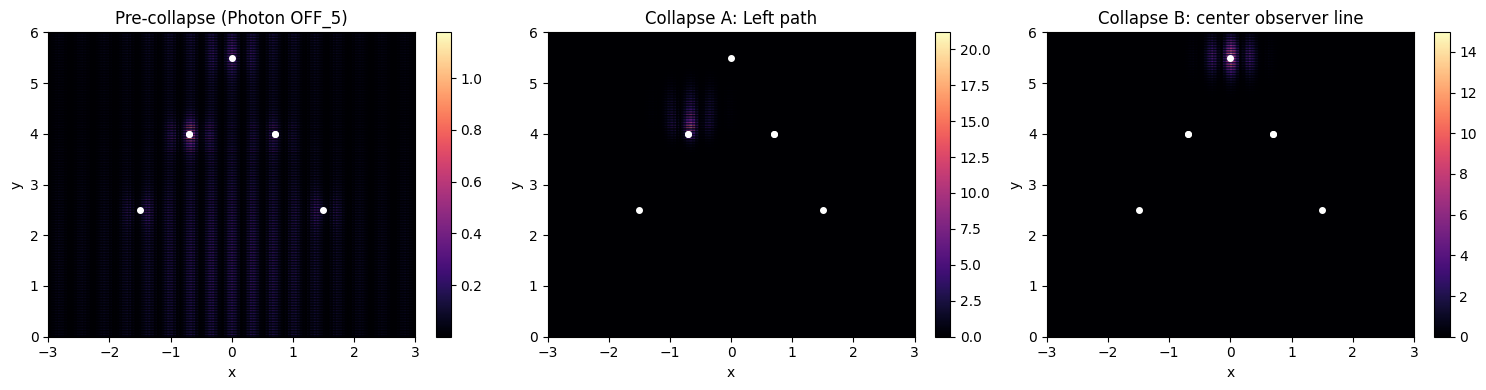

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# 1. Grid
# -----------------------------
Nx, Ny = 600, 600
x = np.linspace(-3, 3, Nx)
y = np.linspace(0, 6, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]

# -----------------------------
# 2. Source + double slit
# -----------------------------
slit_y = 1.0
slit_sep = 1.0
slit_w  = 0.15

def make_initial_psi():
    psi0 = np.zeros_like(X, dtype=complex)
    src_mask = np.exp(-((X-0.0)**2 + (Y-0.2)**2)/0.05)
    psi0 += src_mask * np.exp(1j * 8*Y)

    slit_region = np.abs(Y - slit_y) < 0.05
    slit1 = slit_region & (np.abs(X + slit_sep/2) < slit_w/2)
    slit2 = slit_region & (np.abs(X - slit_sep/2) < slit_w/2)
    mask_slit = np.zeros_like(X, dtype=float)
    mask_slit[slit1 | slit2] = 1.0

    psi0 *= mask_slit
    psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)
    return psi0

# -----------------------------
# 3. Mirrors
# -----------------------------
m1_y = 2.5
m1_xL = -1.5
m1_xR =  1.5
m1_w  = 0.1

m1L = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xL) < m1_w)
m1R = (np.abs(Y - m1_y) < 0.05) & (np.abs(X - m1_xR) < m1_w)

m2_y = 4.0
m2_xL = -0.7
m2_xR =  0.7
m2_w  = 0.1

m2L = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xL) < m2_w)
m2R = (np.abs(Y - m2_y) < 0.05) & (np.abs(X - m2_xR) < m2_w)

# -----------------------------
# 4. Propagation operator
# -----------------------------
kx = np.fft.fftfreq(Nx, d=dx) * 2*np.pi
ky = np.fft.fftfreq(Ny, d=dy) * 2*np.pi
KX, KY = np.meshgrid(kx, ky)

def propagate_step(psi, dz, k0=10.0):
    psi_k = np.fft.fftn(psi)
    phase = np.exp(-1j * (KX**2 + KY**2) * dz / (2*k0))
    psi_k *= phase
    out = np.fft.ifftn(psi_k)
    out /= np.sqrt(np.sum(np.abs(out)**2) * dx * dy)
    return out

# -----------------------------
# 5. Mirror action
# -----------------------------
def apply_mirrors(psi):
    psi_m = psi.copy()

    phase_L1 = np.exp(1j * (3*X + 3*Y))
    phase_R1 = np.exp(1j * (-3*X + 3*Y))
    psi_m[m1L] *= phase_L1[m1L]
    psi_m[m1R] *= phase_R1[m1R]

    phase_L2 = np.exp(1j * (2*(X-0.0) + 3*(Y-5.5)))
    phase_R2 = np.exp(1j * (-2*(X-0.0) + 3*(Y-5.5)))
    psi_m[m2L] *= phase_L2[m2L]
    psi_m[m2R] *= phase_R2[m2R]

    return psi_m

# -----------------------------
# 6. Observers
# -----------------------------
def obs_mask(cx, cy, sigma=0.2):
    return np.exp(-((X-cx)**2 + (Y-cy)**2)/(2*sigma**2))

center = (0.0, 5.5)
obs_R_path = (-0.7, 4.0)
obs_L_path = (0.7, 4.0)

obs_m1L = (m1_xL, m1_y)
obs_m1R = (m1_xR, m1_y)
obs_m2L = (m2_xL, m2_y)
obs_m2R = (m2_xR, m2_y)

obs_centers = [
    center,
    obs_R_path,
    obs_L_path,
    obs_m1L,
    obs_m1R,
    obs_m2L,
    obs_m2R,
]

labels = [
    "Center",
    "Right (on left path)",
    "Left (on right path)",
    "Mirror 1 Left",
    "Mirror 1 Right",
    "Mirror 2 Left",
    "Mirror 2 Right",
]

obs_masks = [obs_mask(*c, sigma=0.25) for c in obs_centers]

idx_center = 0
idx_R_path = 1
idx_L_path = 2

# -----------------------------
# 7. Time + shutter parameters
# -----------------------------
base_dz = 0.05
dt = base_dz

T_prop = 1.0
f_TC = 0.5 / T_prop
omega_TC = 2 * np.pi * f_TC

def global_shutter(t):
    return 1.0 if np.cos(omega_TC * t) > 0 else 0.0

# same randomized pattern for all photons
rng = np.random.default_rng(42)

def per_observer_shutters(step_index):
    mods = np.ones(len(obs_centers))
    rand_L = rng.choice([0.0, 1.0])
    rand_R = rng.choice([0.0, 1.0])
    mods[idx_L_path] *= rand_L
    mods[idx_R_path] *= rand_R
    return mods

# -----------------------------
# 8. Info + mass parameters
# -----------------------------
observer_strength_base = 0.6
info_scale_extract = 1.0
info_scale_inject  = 1.0
S_gamma = 0.03
M0 = 1.0
mass_alpha = 5.0

def info_exchange_step_tunable(psi, cumulative_info, t, step_index):
    psi_o = psi.copy()
    local_I = []
    dI_ext_list = []
    dI_inj_list = []

    g_global = observer_strength_base * global_shutter(t)
    per_obs_mods = per_observer_shutters(step_index)

    g_eff_list = []

    for j, m in enumerate(obs_masks):
        g_eff = g_global * per_obs_mods[j]
        g_eff_list.append(g_eff)

        I_loc = np.sum(np.abs(psi_o)**2 * m * dx * dy)
        local_I.append(I_loc)

        dI_ext = info_scale_extract * g_eff * I_loc
        dI_inj = info_scale_inject  * g_eff * I_loc

        dI_ext_list.append(dI_ext)
        dI_inj_list.append(dI_inj)

        psi_o = psi_o * (1.0 + g_eff * m)

    psi_o /= np.sqrt(np.sum(np.abs(psi_o)**2) * dx * dy)

    total_step_info = np.sum(dI_ext_list) + np.sum(dI_inj_list)
    cumulative_info += total_step_info
    mass_complexity = M0 + mass_alpha * cumulative_info

    return psi_o, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff_list, g_global

# -----------------------------
# 9. Collapse projectors
# -----------------------------
path_L_mask = np.exp(-((X + 0.7)**2 + (Y-4.5)**2)/0.4)
path_R_mask = np.exp(-((X - 0.7)**2 + (Y-4.5)**2)/0.4)
center_line_mask = np.exp(-((X-0.0)**2 + (Y-5.5)**2)/0.4)

def project_and_normalize(psi, mask):
    psi_c = psi * mask
    norm = np.sqrt(np.sum(np.abs(psi_c)**2) * dx * dy)
    if norm < 1e-12:
        return psi_c
    psi_c /= norm
    return psi_c

# -----------------------------
# 10. Single-photon simulation with given emission time
# -----------------------------
segments = [
    ("slit_to_m1", 10, base_dz, False),
    ("at_m1",       1, 0.00,    True),
    ("m1_to_m2",   10, base_dz, False),
    ("at_m2",       1, 0.00,    True),
    ("m2_to_final",15, base_dz, False),
]

def simulate_single_photon(t0, photon_id):
    psi = make_initial_psi()
    cumulative_info = 0.0
    mass_complexity = M0
    t = t0
    step_counter = 0

    collapse_triggered = False
    collapse_point = None
    collapse_cause_label = None
    collapse_type = None

    psi_pre_collapse = None
    psi_path = None
    psi_center = None

    for seg_name, steps, dz, do_mirrors in segments:
        for s in range(steps):
            if dz > 0:
                psi = propagate_step(psi, dz)
                t += dt

            if do_mirrors and s == 0:
                psi = apply_mirrors(psi)

            psi, cumulative_info, mass_complexity, local_I, dI_ext_list, dI_inj_list, g_eff_list, g_global = \
                info_exchange_step_tunable(psi, cumulative_info, t, step_counter)

            step_id = f"{seg_name}_step_{s}"

            if not collapse_triggered and cumulative_info >= S_gamma:
                collapse_triggered = True
                collapse_point = step_id
                psi_pre_collapse = psi.copy()

                total_step_info = np.array(dI_ext_list) + np.array(dI_inj_list)
                max_idx = int(np.argmax(total_step_info))
                collapse_cause_label = labels[max_idx]

                if collapse_cause_label == "Center":
                    psi_center = project_and_normalize(psi, center_line_mask)
                    collapse_type = "Center (tunneling-like)"
                    I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                    I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                    if I_L >= I_R:
                        psi_path = project_and_normalize(psi, path_L_mask)
                    else:
                        psi_path = project_and_normalize(psi, path_R_mask)
                else:
                    I_L = np.sum(np.abs(psi)**2 * path_L_mask * dx * dy)
                    I_R = np.sum(np.abs(psi)**2 * path_R_mask * dx * dy)
                    if I_L >= I_R:
                        psi_path = project_and_normalize(psi, path_L_mask)
                        collapse_type = "Left path"
                    else:
                        psi_path = project_and_normalize(psi, path_R_mask)
                        collapse_type = "Right path"
                    psi_center = project_and_normalize(psi, center_line_mask)

            step_counter += 1

        if collapse_triggered:
            break

    if not collapse_triggered:
        collapse_point = "No collapse (info below S_gamma)"
        collapse_cause_label = "None"
        collapse_type = "None"
        psi_pre_collapse = psi.copy()
        psi_path = psi.copy()
        psi_center = psi.copy()

    result = {
        "photon_id": photon_id,
        "t0": t0,
        "collapse_triggered": collapse_triggered,
        "collapse_point": collapse_point,
        "collapse_cause_label": collapse_cause_label,
        "collapse_type": collapse_type,
        "cumulative_info": cumulative_info,
        "mass_complexity": mass_complexity,
        "psi_pre_collapse": psi_pre_collapse,
        "psi_path": psi_path,
        "psi_center": psi_center,
    }
    return result

# -----------------------------
# 11. Choose emission times: 5 with shutter ON, 5 with shutter OFF
# -----------------------------
# global_shutter(t) = 1 if cos(ω t) > 0, 0 otherwise
# ON at t = 0, OFF at t = π/ω_TC (center of off region)
t_on  = 0.0
t_off = np.pi / omega_TC

results = []

for i in range(5):
    results.append(simulate_single_photon(t_on,  f"ON_{i+1}"))
for i in range(5):
    results.append(simulate_single_photon(t_off, f"OFF_{i+1}"))

# -----------------------------
# 12. Print summary
# -----------------------------
print("=== Multi-Photon Summary (tied to shutter state at emission) ===")
for r in results:
    print(f"Photon {r['photon_id']}: t0={r['t0']:.4e}, "
          f"collapse={r['collapse_triggered']}, point={r['collapse_point']}, "
          f"cause={r['collapse_cause_label']}, type={r['collapse_type']}, "
          f"ΣI={r['cumulative_info']:.4f}, M={r['mass_complexity']:.4f}")

# -----------------------------
# 13. Plot last photon fields
# -----------------------------
last = results[-1]
psi_pre_collapse = last["psi_pre_collapse"]
psi_path = last["psi_path"]
psi_center = last["psi_center"]

print("\nNormalization checks (last photon):")
print("  ∑|psi_pre_collapse|^2 dx dy:", np.sum(np.abs(psi_pre_collapse)**2) * dx * dy)
print("  ∑|psi_path|^2 dx dy:        ", np.sum(np.abs(psi_path)**2) * dx * dy)
print("  ∑|psi_center|^2 dx dy:      ", np.sum(np.abs(psi_center)**2) * dx * dy)

fig, ax = plt.subplots(1, 3, figsize=(15,4))

im0 = ax[0].imshow(np.abs(psi_pre_collapse)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[0].set_title(f'Pre-collapse (Photon {last["photon_id"]})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(np.abs(psi_path)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[1].set_title(f'Collapse A: {last["collapse_type"]}')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
plt.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(np.abs(psi_center)**2,
                   extent=[x[0], x[-1], y[0], y[-1]],
                   origin='lower', cmap='magma', aspect='auto')
ax[2].set_title('Collapse B: center observer line')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
plt.colorbar(im2, ax=ax[2], fraction=0.046)

for (cx, cy) in obs_centers:
    for a in ax:
        a.plot(cx, cy, 'wo', ms=4)

plt.tight_layout()
plt.show()

Discussion: The New Grand Field Theory (NGFT) as explored in these simulations proposes a radical departure from standard physics, particularly quantum mechanics, in several fundamental ways:

Nature of Fundamental Reality:

Standard Physics (Quantum Mechanics - QM): Views reality as fundamentally composed of particles and/or quantum fields described by wavefunctions. These wavefunctions evolve deterministically according to the Schrödinger equation, but collapse probabilistically upon measurement into a definite state.
NGFT: Proposes that reality is fundamentally an informational field. Particles, causality, and even spacetime itself might be emergent properties of this deeper informational manifold. The 'photon' or 'electron' is not a particle in the classical sense, nor strictly a wavefunction in the QM sense, but rather a manifestation within this informational field.
The Measurement Problem (Observation):

Standard Physics (QM): This is one of QM's most profound and unresolved issues. The wavefunction 'collapses' instantaneously and acausally upon observation, but what constitutes an observation is ill-defined. While decoherence explains how quantum superposition transitions to classical mixtures due to environmental interaction, it doesn't fully explain the selection of a single outcome.
NGFT: Offers a continuous, deterministic mechanism for observation. It's local sampling and back-action, where observers subtly reshape the informational field. 'Collapse' isn't instantaneous or acausal; instead, it's a thresholded informational transition. When sufficient information (S_gamma) about a field's state is accumulated through these local interactions, the field's configuration is driven into a localized, classical-like state. This is a gradual process of information-induced localization rather than an abrupt, undefined collapse.
Causality and Non-Locality:

Standard Physics (QM): While the evolution of the wavefunction is causally local, QM famously features non-local correlations (e.g., entanglement) that defy classical causal explanations (Bell's theorem). However, it upholds the principle that information cannot be transmitted faster than light.
NGFT: Explicitly suggests that the underlying informational field operates in a non-local, non-causally-ordered space. What we perceive as cause-and-effect in spacetime is an emergent, approximate phenomenon—a "macroscopic shadow" of the deeper informational dynamics. The observation in the simulations where a 'downstream' observer (Mirror 2 Right) triggers an early 'collapse' point (slit_to_m1_step_1) is a direct illustration of this inherent non-locality and emergent causality.
Role of Information:

Standard Physics (QM): Information is generally considered a consequence of a measurement. While quantum information theory is a rich field, information itself isn't typically seen as a primary driver of fundamental physical dynamics in the same way.
NGFT: Information is fundamental and dynamic. The exchange, accumulation, and budget of information are central to how the informational field evolves and transitions between different states. cumulative_info directly influences mass_complexity, suggesting a profound link between information and fundamental physical properties.
Stochasticity and Determinism:

Standard Physics (QM): Presents an inherent probabilistic element in measurement outcomes, suggesting a fundamental randomness at the quantum level.
NGFT: While the field evolution might be deterministic, the simulations introduced stochastic elements in the observers' interactions. This means that the probabilistic outcomes of 'collapse' could emerge from the random nature of these observer-field interactions within a largely deterministic underlying framework, rather than being an intrinsic, irreducible property of the quantum state itself.
In essence, NGFT aims to provide a more holistic and unified explanation for quantum phenomena, moving beyond the interpretive difficulties of standard QM by positing a deeper informational reality where concepts like observation, causality, and particles are reinterpreted as emergent properties of a dynamic, non-local informational field.